# Phase 2 — Advanced Analytics & Visualization

## 1. Introduction

**Phase 1** (`sales_analytics_pipeline.ipynb`) loaded Olist CSVs into PostgreSQL, built staging tables, and created the analytical fact table **`fact_sales`** (grain: `order_id` + `order_item_id`).

**Phase 2** continues from that model to deliver:

1. **Advanced SQL analytics** — growth, cohorts, RFM, Pareto, trends  
2. **Python visualizations** — charts for stakeholders  
3. **Seasonality patterns** — monthly, quarterly, and weekday cycles  
4. **Business insights** — actionable takeaways  

> **Prerequisite:** Phase 1 completed; `fact_sales` and staging tables exist in `sales_db`.


## 2. Library Imports & PostgreSQL Connection

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sqlalchemy import create_engine, text
from sqlalchemy.engine import Engine

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

ASSUMED_MARGIN = 0.30

# Must match Phase 1 credentials. User is 'postgres' (not 'postgresql').
PG_USER = os.environ.get("PGUSER", "postgres")
PG_PASSWORD = os.environ.get("PGPASSWORD", "kanna")
PG_HOST = os.environ.get("PGHOST", "localhost")
PG_PORT = os.environ.get("PGPORT", "5432")
PG_DATABASE = os.environ.get("PGDATABASE", "sales_db")

CONNECTION_STRING = os.environ.get(
    "DATABASE_URL",
    f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DATABASE}",
)

engine: Engine = create_engine(CONNECTION_STRING)

FACT_CUSTOMER_JOIN = """
FROM fact_sales f
JOIN staging_orders o
  ON f.order_id = o.order_id AND f.order_item_id = o.order_item_id
LEFT JOIN staging_customers c ON o.customer_id = c.customer_id
"""


def run_sql(sql: str, params: dict | None = None) -> pd.DataFrame:
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn, params=params or {})


print("PostgreSQL connection ready (Phase 1 tables required).")


PostgreSQL connection ready (Phase 1 tables required).


## 3. Load Data from PostgreSQL

Reads the full `fact_sales` table into pandas for profiling and charts.


In [2]:
df_fact = run_sql("SELECT * FROM fact_sales")

print(f"Rows: {df_fact.shape[0]:,}  |  Columns: {df_fact.shape[1]}")
display(df_fact.head(10))

print("\n--- Summary statistics ---")
display(df_fact.describe(include="all").T)

print("\n--- Missing values ---")
display(df_fact.isna().sum().to_frame("null_count"))


Rows: 112,650  |  Columns: 17


,order_id,order_item_id,order_date,customer_location,product_category,price,quantity,total_revenue,payment_type,delivery_time,freight_value,seller_id,seller_region,review_score,payment_installments,customer_lat,customer_lng
0,bfbd0f9bdef84302105ad712db648a6c,3,2016-09-15,sao joaquim da barra,health_beauty,44.99,1,44.99,Unknown,55.0,2.83,ecccfa2bb93b34a3bf033cc5d1dcdc69,PR,1.0,NaN,-20.585751,-47.863693
1,bfbd0f9bdef84302105ad712db648a6c,2,2016-09-15,sao joaquim da barra,health_beauty,44.99,1,44.99,Unknown,55.0,2.83,ecccfa2bb93b34a3bf033cc5d1dcdc69,PR,1.0,NaN,-20.585751,-47.863693
2,bfbd0f9bdef84302105ad712db648a6c,1,2016-09-15,sao joaquim da barra,health_beauty,44.99,1,44.99,Unknown,55.0,2.83,ecccfa2bb93b34a3bf033cc5d1dcdc69,PR,1.0,NaN,-20.585751,-47.863693
3,18dad78c0f87f4c45ef196daeaa3ffbb,1,2016-10-05,londrina,computers_accessories,43.89,1,43.89,credit_card,12.0,14.52,8c16d1f32a54d92897cc437244442e1b,SC,5.0,1.0,-23.318127,-51.157136
4,a241bea87dcdd0160ca94ebdba5bdbb9,1,2016-10-06,maua,perfumery,279.90,1,279.90,credit_card,7.0,17.45,620c87c171fb2a6dd6e8bb4dec959fc6,RJ,5.0,5.0,-23.678575,-46.465084
5,cd3b8574c82b42fc8129f6d502690c3e,1,2016-10-03,taubate,fashion_shoes,29.99,1,29.99,credit_card,11.0,10.96,b499c00f28f4b7069ff6550af8c1348a,SP,5.0,4.0,-23.032142,-45.570461
6,323dad8c483c7f8b818a825d257f4aa0,1,2016-10-06,sao paulo,telephony,29.90,1,29.90,credit_card,8.0,8.72,2138ccb85b11a4ec1e37afbd1c8eda1f,SP,5.0,1.0,-23.601092,-46.553696
7,36989eb07a0de2d3d3129eea35553875,2,2016-10-04,cuiaba,furniture_decor,23.90,1,23.90,credit_card,7.0,26.82,939f6e231201f26803cb5c3a3d2940b3,SP,5.0,10.0,-15.607627,-56.033979
8,36989eb07a0de2d3d3129eea35553875,1,2016-10-04,cuiaba,furniture_decor,23.90,1,23.90,credit_card,7.0,26.82,939f6e231201f26803cb5c3a3d2940b3,SP,5.0,10.0,-15.607627,-56.033979
9,b3aa45b7ba0f950a1b163a9f85f613de,1,2016-10-09,belo horizonte,housewares,44.99,1,44.99,credit_card,10.0,15.53,11305281b50fff20ae8bb473f8e11876,MG,4.0,1.0,-19.832231,-43.952956



--- Summary statistics ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,112650,98666,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_item_id,112650.0,NaN,NaN,NaN,1.197834,0.705124,1.0,1.0,1.0,1.0,21.0
order_date,112650,616,2017-11-24,1366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_location,112650,4110,sao paulo,17808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,112650,74,bed_bath_table,11115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,112650.0,NaN,NaN,NaN,120.653739,183.633928,0.85,39.9,74.99,134.9,6735.0
quantity,112650.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
total_revenue,112650.0,NaN,NaN,NaN,120.653739,183.633928,0.85,39.9,74.99,134.9,6735.0
payment_type,112650,5,credit_card,86434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_time,110196.0,NaN,NaN,NaN,12.410959,9.455147,0.0,7.0,10.0,16.0,210.0



--- Missing values ---


,null_count
order_id,0
order_item_id,0
order_date,0
customer_location,0
product_category,0
price,0
quantity,0
total_revenue,0
payment_type,0
delivery_time,2454


---
## 4. Advanced SQL Analytics (12 queries)

Customer-level metrics join `staging_orders` and `staging_customers` (Phase 1 design).


### 4.1 Year-over-Year Revenue Growth

In [3]:
q01_yoy = run_sql('''
WITH yearly AS (
    SELECT EXTRACT(YEAR FROM order_date)::INT AS yr,
           SUM(total_revenue) AS revenue
    FROM fact_sales
    GROUP BY 1
)
SELECT yr, revenue,
       LAG(revenue) OVER (ORDER BY yr) AS prev_year_revenue,
       ROUND(100.0 * (revenue - LAG(revenue) OVER (ORDER BY yr))
             / NULLIF(LAG(revenue) OVER (ORDER BY yr), 0), 2) AS yoy_growth_pct
FROM yearly
ORDER BY yr
''')
q01_yoy


,yr,revenue,prev_year_revenue,yoy_growth_pct
0,2016,49785.92,NaN,NaN
1,2017,6155806.98,49785.92,12264.55
2,2018,7386050.80,6155806.98,19.99


### 4.2 Month-over-Month Revenue Growth

In [4]:
q02_mom = run_sql('''
WITH monthly AS (
    SELECT DATE_TRUNC('month', order_date)::DATE AS month_start,
           SUM(total_revenue) AS revenue
    FROM fact_sales
    GROUP BY 1
)
SELECT month_start, revenue,
       LAG(revenue) OVER (ORDER BY month_start) AS prev_month_revenue,
       ROUND(100.0 * (revenue - LAG(revenue) OVER (ORDER BY month_start))
             / NULLIF(LAG(revenue) OVER (ORDER BY month_start), 0), 2) AS mom_growth_pct
FROM monthly
ORDER BY month_start
''')
q02_mom


,month_start,revenue,prev_month_revenue,mom_growth_pct
0,2016-09-01,267.36,NaN,NaN
1,2016-10-01,49507.66,267.36,18417.23
2,2016-12-01,10.90,49507.66,-99.98
3,2017-01-01,120312.87,10.90,1103687.80
4,2017-02-01,247303.02,120312.87,105.55
5,2017-03-01,374344.30,247303.02,51.37
6,2017-04-01,359927.23,374344.30,-3.85
7,2017-05-01,506071.14,359927.23,40.60
8,2017-06-01,433038.60,506071.14,-14.43
9,2017-07-01,498031.48,433038.60,15.01


### 4.3 Pareto — Revenue from Top 20% of Customers

In [5]:
q03_pareto = run_sql('''
WITH cust_rev AS (
    SELECT o.customer_id, SUM(f.total_revenue) AS customer_revenue
    
FROM fact_sales f
JOIN staging_orders o
  ON f.order_id = o.order_id AND f.order_item_id = o.order_item_id
LEFT JOIN staging_customers c ON o.customer_id = c.customer_id

    GROUP BY o.customer_id
),
ranked AS (
    SELECT customer_revenue,
           PERCENT_RANK() OVER (ORDER BY customer_revenue DESC) AS pct_rank_desc
    FROM cust_rev
)
SELECT COUNT(*) FILTER (WHERE pct_rank_desc <= 0.20) AS customers_top_20pct,
       COUNT(*) AS total_customers,
       ROUND(SUM(customer_revenue) FILTER (WHERE pct_rank_desc <= 0.20), 2) AS revenue_top_20pct,
       ROUND(SUM(customer_revenue), 2) AS total_revenue,
       ROUND(100.0 * SUM(customer_revenue) FILTER (WHERE pct_rank_desc <= 0.20)
             / NULLIF(SUM(customer_revenue), 0), 2) AS pct_revenue_from_top_20pct
FROM ranked
''')
q03_pareto


,customers_top_20pct,total_customers,revenue_top_20pct,total_revenue,pct_revenue_from_top_20pct
0,19737,98666,7682726.18,13591643.7,56.53


### 4.4 Cohort Analysis — Retention by Month

In [6]:
q04_cohort = run_sql('''
WITH orders AS (
    SELECT DISTINCT o.customer_id, DATE_TRUNC('month', f.order_date)::DATE AS order_month
    
FROM fact_sales f
JOIN staging_orders o
  ON f.order_id = o.order_id AND f.order_item_id = o.order_item_id
LEFT JOIN staging_customers c ON o.customer_id = c.customer_id

),
first_order AS (
    SELECT customer_id, MIN(order_month) AS cohort_month FROM orders GROUP BY 1
),
activity AS (
    SELECT fo.cohort_month, o.order_month,
           (EXTRACT(YEAR FROM AGE(o.order_month, fo.cohort_month)) * 12
            + EXTRACT(MONTH FROM AGE(o.order_month, fo.cohort_month)))::INT AS months_since_first,
           COUNT(DISTINCT o.customer_id) AS active_customers
    FROM orders o
    JOIN first_order fo ON o.customer_id = fo.customer_id
    GROUP BY 1, 2, 3
),
sizes AS (SELECT cohort_month, COUNT(*) AS cohort_size FROM first_order GROUP BY 1)
SELECT a.cohort_month, a.months_since_first, s.cohort_size, a.active_customers,
       ROUND(100.0 * a.active_customers / NULLIF(s.cohort_size, 0), 2) AS retention_pct
FROM activity a JOIN sizes s ON a.cohort_month = s.cohort_month
WHERE a.months_since_first <= 12
ORDER BY a.cohort_month, a.months_since_first
''')
display(q04_cohort.head(24))


,cohort_month,months_since_first,cohort_size,active_customers,retention_pct
0,2016-09-01,0,3,3,100.0
1,2016-10-01,0,308,308,100.0
2,2016-12-01,0,1,1,100.0
3,2017-01-01,0,789,789,100.0
4,2017-02-01,0,1733,1733,100.0
5,2017-03-01,0,2641,2641,100.0
6,2017-04-01,0,2391,2391,100.0
7,2017-05-01,0,3660,3660,100.0
8,2017-06-01,0,3217,3217,100.0
9,2017-07-01,0,3969,3969,100.0


### 4.5 RFM Segmentation

In [7]:
q05_rfm = run_sql('''
WITH m AS (
    SELECT o.customer_id, MAX(f.order_date) AS last_order,
           COUNT(DISTINCT f.order_id) AS frequency, SUM(f.total_revenue) AS monetary
    
FROM fact_sales f
JOIN staging_orders o
  ON f.order_id = o.order_id AND f.order_item_id = o.order_item_id
LEFT JOIN staging_customers c ON o.customer_id = c.customer_id

    GROUP BY o.customer_id
),
scored AS (
    SELECT (CURRENT_DATE - last_order) AS recency_days, frequency, monetary,
           NTILE(5) OVER (ORDER BY (CURRENT_DATE - last_order) ASC) AS r_score,
           NTILE(5) OVER (ORDER BY frequency DESC) AS f_score,
           NTILE(5) OVER (ORDER BY monetary DESC) AS m_score
    FROM m
),
seg AS (
    SELECT *,
           CASE WHEN r_score >= 4 AND f_score >= 4 THEN 'Champions'
                WHEN r_score >= 3 AND f_score >= 3 THEN 'Loyal'
                WHEN r_score >= 4 AND f_score <= 2 THEN 'New / Promising'
                WHEN r_score <= 2 AND f_score >= 3 THEN 'At Risk'
                WHEN r_score <= 2 AND f_score <= 2 THEN 'Hibernating'
                ELSE 'Needs Attention' END AS rfm_segment
    FROM scored
)
SELECT rfm_segment, COUNT(*) AS customers,
       ROUND(AVG(recency_days), 1) AS avg_recency_days,
       ROUND(AVG(frequency), 2) AS avg_orders,
       ROUND(AVG(monetary), 2) AS avg_spend
FROM seg GROUP BY 1 ORDER BY customers DESC
''')
q05_rfm


,rfm_segment,customers,avg_recency_days,avg_orders,avg_spend
0,At Risk,23546,2911.0,1.0,141.47
1,Loyal,19847,3112.3,1.0,135.46
2,Hibernating,15921,2911.4,1.0,138.62
3,Champions,15806,3217.1,1.0,138.03
4,New / Promising,15705,3216.7,1.0,138.99
5,Needs Attention,7841,3042.3,1.0,127.63


### 4.6 Revenue Heatmap — Day of Week × Month

In [8]:
q06_heatmap = run_sql('''
SELECT EXTRACT(MONTH FROM order_date)::INT AS month_num,
       TO_CHAR(order_date, 'Dy') AS day_of_week,
       EXTRACT(DOW FROM order_date)::INT AS dow_num,
       SUM(total_revenue) AS revenue
FROM fact_sales
GROUP BY 1, 2, 3
ORDER BY month_num, dow_num
''')
q06_heatmap.head(14)


,month_num,day_of_week,dow_num,revenue
0,1,Sun,0,121312.20
1,1,Mon,1,172976.18
2,1,Tue,2,185944.80
3,1,Wed,3,186662.98
4,1,Thu,4,151648.68
5,1,Fri,5,141549.85
6,1,Sat,6,110248.54
7,2,Sun,0,133165.49
8,2,Mon,1,166660.17
9,2,Tue,2,180937.48


### 4.7 Category Performance Trend

In [9]:
q07_category_trend = run_sql('''
SELECT DATE_TRUNC('month', order_date)::DATE AS month_start,
       product_category, SUM(total_revenue) AS revenue
FROM fact_sales
GROUP BY 1, 2
ORDER BY month_start, revenue DESC
''')
q07_category_trend.head(20)


,month_start,product_category,revenue
0,2016-09-01,health_beauty,134.97
1,2016-09-01,furniture_decor,72.89
2,2016-09-01,telephony,59.50
3,2016-10-01,furniture_decor,5807.89
4,2016-10-01,perfumery,5688.70
5,2016-10-01,health_beauty,4552.51
6,2016-10-01,toys,4465.09
7,2016-10-01,consoles_games,3882.26
8,2016-10-01,watches_gifts,3360.24
9,2016-10-01,sports_leisure,3333.64


### 4.8 Region-Wise Profitability (30% Assumed Margin)

In [10]:
q08_region_profit = run_sql('''
SELECT COALESCE(NULLIF(TRIM(c.region), ''), 'Unknown') AS region,
       SUM(f.total_revenue) AS revenue,
       ROUND(SUM(f.total_revenue) * 0.3, 2) AS estimated_profit,
       COUNT(DISTINCT f.order_id) AS orders

FROM fact_sales f
JOIN staging_orders o
  ON f.order_id = o.order_id AND f.order_item_id = o.order_item_id
LEFT JOIN staging_customers c ON o.customer_id = c.customer_id

GROUP BY 1 ORDER BY estimated_profit DESC
''')
q08_region_profit


,region,revenue,estimated_profit,orders
0,SP,5202955.05,1560886.52,41375
1,RJ,1824092.67,547227.80,12762
2,MG,1585308.03,475592.41,11544
3,RS,750304.02,225091.21,5432
4,PR,683083.76,204925.13,4998
5,SC,520553.34,156166.00,3612
6,BA,511349.99,153405.00,3358
7,DF,302603.94,90781.18,2125
8,GO,294591.95,88377.59,2007
9,ES,275037.31,82511.19,2025


### 4.9 Delivery Performance Trend by Month

In [11]:
q09_delivery = run_sql('''
SELECT DATE_TRUNC('month', order_date)::DATE AS month_start,
       ROUND(AVG(delivery_time)::NUMERIC, 2) AS avg_delivery_days,
       COUNT(delivery_time) AS n
FROM fact_sales WHERE delivery_time IS NOT NULL
GROUP BY 1 ORDER BY 1
''')
q09_delivery


,month_start,avg_delivery_days,n
0,2016-09-01,55.00,3
1,2016-10-01,19.56,319
2,2016-12-01,5.00,1
3,2017-01-01,12.75,913
4,2017-02-01,13.31,1858
5,2017-03-01,13.08,2897
6,2017-04-01,14.95,2569
7,2017-05-01,11.56,4003
8,2017-06-01,11.99,3489
9,2017-07-01,11.33,4416


### 4.10 Payment Type Analysis

In [12]:
q10_payments = run_sql('''
SELECT f.payment_type, pay.payment_status,
       COUNT(DISTINCT f.order_id) AS orders,
       SUM(f.total_revenue) AS revenue,
       ROUND(AVG(f.payment_installments)::NUMERIC, 2) AS avg_installments
FROM fact_sales f
LEFT JOIN staging_payments pay ON f.order_id = pay.order_id
GROUP BY 1, 2 ORDER BY revenue DESC
''')
q10_payments


,payment_type,payment_status,orders,revenue,avg_installments
0,credit_card,Completed,75990,10883702.27,3.63
1,boleto,Completed,19614,2391525.66,1.00
2,debit_card,Completed,1521,183730.84,1.00
3,voucher,Completed,1540,132549.96,1.00
4,Unknown,NaN,1,134.97,NaN


### 4.11 Order Frequency Distribution

In [13]:
q11_freq = run_sql('''
WITH co AS (
    SELECT o.customer_id, COUNT(DISTINCT f.order_id) AS order_count
    
FROM fact_sales f
JOIN staging_orders o
  ON f.order_id = o.order_id AND f.order_item_id = o.order_item_id
LEFT JOIN staging_customers c ON o.customer_id = c.customer_id

    GROUP BY o.customer_id
)
SELECT order_count, COUNT(*) AS customer_count FROM co GROUP BY 1 ORDER BY 1
''')
q11_freq


,order_count,customer_count
0,1,98666


### 4.12 Customer Lifetime Revenue

In [14]:
q12_clv = run_sql('''
SELECT o.customer_id, c.customer_name, c.region,
       SUM(f.total_revenue) AS lifetime_revenue,
       COUNT(DISTINCT f.order_id) AS total_orders,
       MIN(f.order_date) AS first_order, MAX(f.order_date) AS last_order

FROM fact_sales f
JOIN staging_orders o
  ON f.order_id = o.order_id AND f.order_item_id = o.order_item_id
LEFT JOIN staging_customers c ON o.customer_id = c.customer_id

GROUP BY 1, 2, 3 ORDER BY lifetime_revenue DESC LIMIT 50
''')
q12_clv.head(15)


,customer_id,customer_name,region,lifetime_revenue,total_orders,first_order,last_order
0,1617b1357756262bfa56ab541c47bc16,"rio de janeiro, RJ",RJ,13440.00,1,2017-09-29,2017-09-29
1,ec5b2ba62e574342386871631fafd3fc,"vila velha, ES",ES,7160.00,1,2018-07-15,2018-07-15
2,c6e2731c5b391845f6800c97401a43a9,"campo grande, MS",MS,6735.00,1,2017-02-12,2017-02-12
3,f48d464a0baaea338cb25f816991ab1f,"vitoria, ES",ES,6729.00,1,2018-07-25,2018-07-25
4,3fd6777bbce08a352fddd04e4a7cc8f6,"marilia, SP",SP,6499.00,1,2017-05-24,2017-05-24
5,05455dfa7cd02f13d132aa7a6a9729c6,"divinopolis, MG",MG,5934.60,1,2017-11-24,2017-11-24
6,df55c14d1476a9a3467f131269c2477f,"araruama, RJ",RJ,4799.00,1,2017-04-01,2017-04-01
7,24bbf5fd2f2e1b359ee7de94defc4a15,"maua, SP",SP,4690.00,1,2017-04-18,2017-04-18
8,e0a2412720e9ea4f26c1ac985f6a7358,"goiania, GO",GO,4599.90,1,2018-07-12,2018-07-12
9,3d979689f636322c62418b6346b1c6d2,"joao pessoa, PB",PB,4590.00,1,2018-06-22,2018-06-22


---
## 4.13–4.16 Seasonality Patterns Analysis

Identifies **recurring calendar patterns** in revenue, orders, categories, and delivery time using `fact_sales`.


### 4.13 Monthly seasonality index (calendar month)

Average revenue and order count by month-of-year (1–12), useful for annual planning cycles.


In [15]:
q13_monthly_seasonality = run_sql('''
SELECT EXTRACT(MONTH FROM order_date)::INT AS calendar_month,
       TO_CHAR(MIN(order_date), 'Mon') AS month_label,
       SUM(total_revenue) AS total_revenue,
       COUNT(DISTINCT order_id) AS orders,
       ROUND(AVG(total_revenue)::NUMERIC, 2) AS avg_line_revenue
FROM fact_sales
GROUP BY 1
ORDER BY calendar_month
''')
q13_monthly_seasonality


,calendar_month,month_label,total_revenue,orders,avg_line_revenue
0,1,Jan,1070343.23,8009,116.81
1,2,Feb,1091481.73,8427,113.42
2,3,Mar,1357557.74,9829,121.03
3,4,Apr,1356574.98,9325,127.27
4,5,May,1502588.82,10513,124.58
5,6,Jun,1298162.91,9377,121.77
6,7,Jul,1393538.70,10242,120.02
7,8,Aug,1428658.01,10745,117.51
8,9,Sep,624814.05,4247,129.15
9,10,Oct,713727.09,4876,125.55


### 4.14 Quarterly revenue seasonality


In [16]:
q14_quarterly = run_sql('''
SELECT EXTRACT(YEAR FROM order_date)::INT AS yr,
       EXTRACT(QUARTER FROM order_date)::INT AS qtr,
       SUM(total_revenue) AS quarterly_revenue,
       COUNT(DISTINCT order_id) AS orders
FROM fact_sales
GROUP BY 1, 2
ORDER BY yr, qtr
''')
q14_quarterly


,yr,qtr,quarterly_revenue,orders
0,2016,3,267.36,3
1,2016,4,49518.56,309
2,2017,1,741960.19,5163
3,2017,2,1299036.97,9268
4,2017,3,1696404.85,12505
5,2017,4,2418404.97,17643
6,2018,1,2777422.51,21102
7,2018,2,2858289.74,19947
8,2018,3,1750338.55,12726


### 4.15 Day-of-week seasonality

Average revenue by weekday (complements the heatmap in section 5).


In [17]:
q15_dow_seasonality = run_sql('''
SELECT EXTRACT(DOW FROM order_date)::INT AS dow_num,
       TO_CHAR(order_date, 'Dy') AS day_of_week,
       SUM(total_revenue) AS total_revenue,
       COUNT(DISTINCT order_id) AS orders,
       ROUND(SUM(total_revenue) / NULLIF(COUNT(DISTINCT order_date), 0), 2) AS avg_daily_revenue
FROM fact_sales
GROUP BY 1, 2
ORDER BY dow_num
''')
q15_dow_seasonality


,dow_num,day_of_week,total_revenue,orders,avg_daily_revenue
0,0,Sun,1589278.89,11888,17857.07
1,1,Mon,2230812.51,16068,24786.81
2,2,Tue,2172647.82,15831,24972.96
3,3,Wed,2113843.59,15425,24297.05
4,4,Thu,2018615.78,14639,22938.82
5,5,Fri,1962426.75,14002,22300.30
6,6,Sat,1504018.36,10813,17287.57


### 4.16 Peak months & delivery seasonality

Ranks months within each year and tracks how average delivery time varies by month.


In [18]:
q16_peak_months = run_sql('''
WITH monthly AS (
    SELECT EXTRACT(YEAR FROM order_date)::INT AS yr,
           DATE_TRUNC('month', order_date)::DATE AS month_start,
           SUM(total_revenue) AS revenue
    FROM fact_sales
    GROUP BY 1, 2
),
ranked AS (
    SELECT *, RANK() OVER (PARTITION BY yr ORDER BY revenue DESC) AS rev_rank
    FROM monthly
)
SELECT yr, month_start, revenue, rev_rank
FROM ranked WHERE rev_rank <= 3
ORDER BY yr, rev_rank
''')
display(q16_peak_months)

q16_delivery_season = run_sql('''
SELECT EXTRACT(MONTH FROM order_date)::INT AS calendar_month,
       ROUND(AVG(delivery_time)::NUMERIC, 2) AS avg_delivery_days,
       COUNT(delivery_time) AS n
FROM fact_sales WHERE delivery_time IS NOT NULL
GROUP BY 1 ORDER BY 1
''')
q16_delivery_season


,yr,month_start,revenue,rev_rank
0,2016,2016-10-01,49507.66,1
1,2016,2016-09-01,267.36,2
2,2016,2016-12-01,10.90,3
3,2017,2017-11-01,1010271.37,1
4,2017,2017-12-01,743914.17,2
5,2017,2017-10-01,664219.43,3
6,2018,2018-04-01,996647.75,1
7,2018,2018-05-01,996517.68,2
8,2018,2018-03-01,983213.44,3


,calendar_month,avg_delivery_days,n
0,1,13.89,8950
1,2,16.14,9377
2,3,15.20,10914
3,4,12.16,10396
4,5,11.35,11813
5,6,10.02,10496
6,7,9.79,11376
7,8,8.89,11939
8,9,11.75,4740
9,10,12.04,5533


### Seasonality visualizations


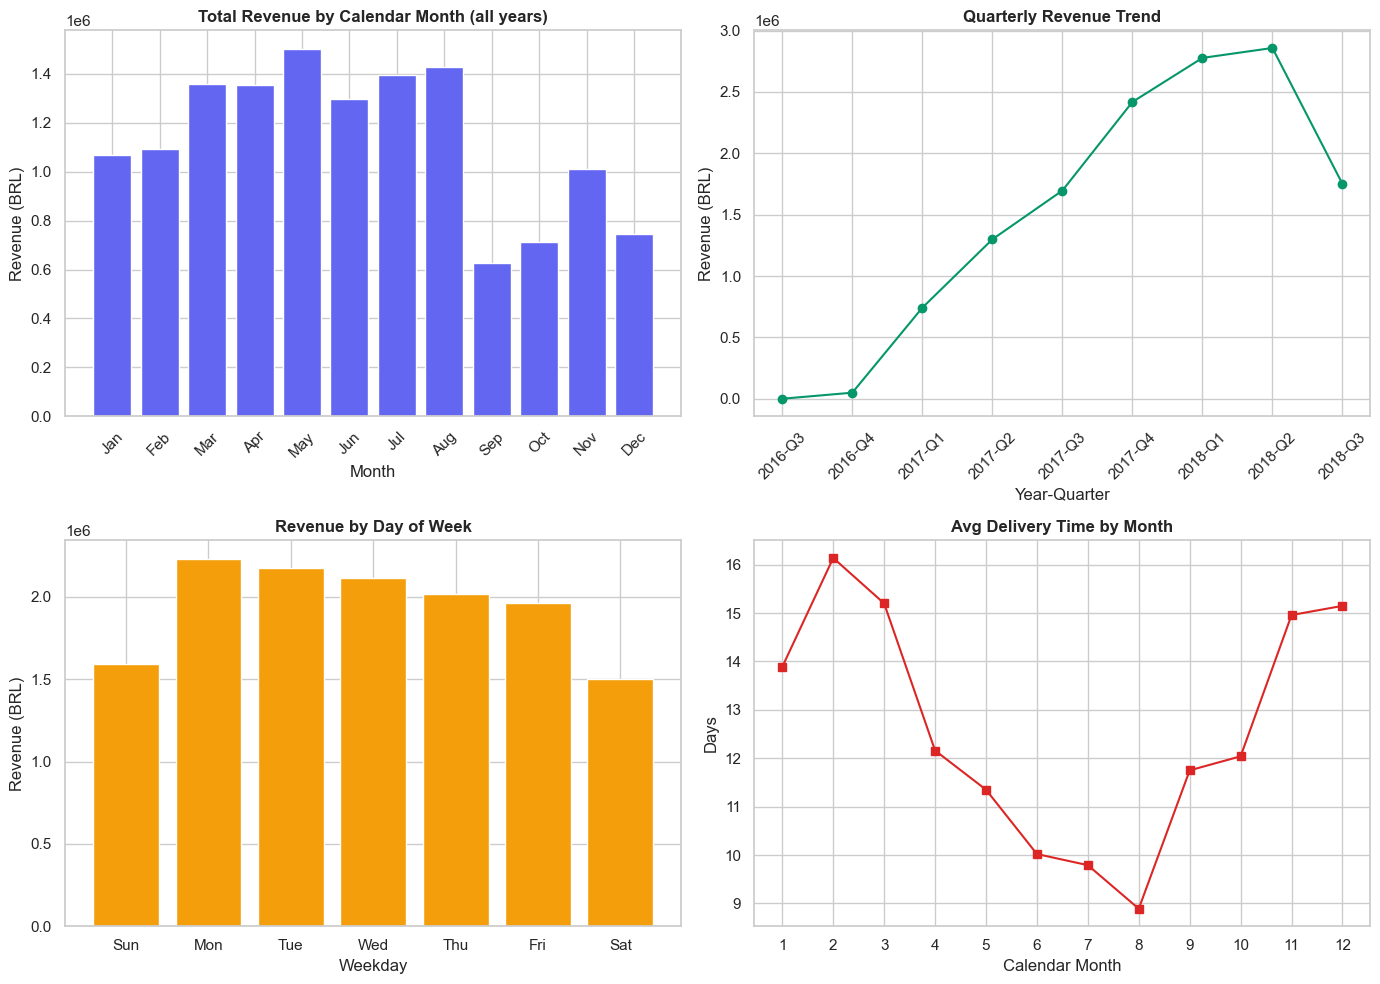

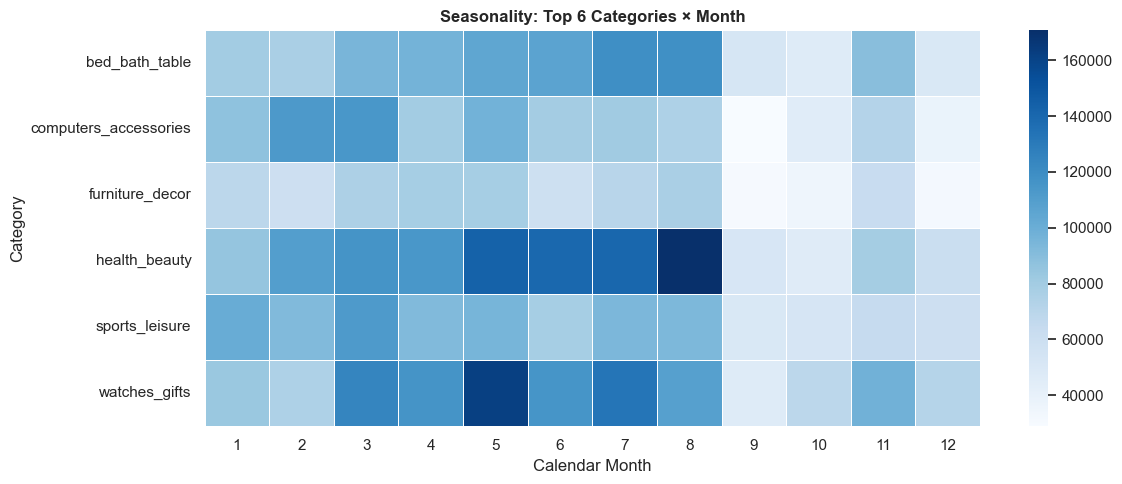

In [19]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
m_idx = q13_monthly_seasonality.set_index('calendar_month').reindex(range(1, 13))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Avg revenue by calendar month
axes[0, 0].bar(month_names, m_idx['total_revenue'].fillna(0), color='#6366f1')
axes[0, 0].set_title('Total Revenue by Calendar Month (all years)', fontweight='bold')
axes[0, 0].set_xlabel('Month'); axes[0, 0].set_ylabel('Revenue (BRL)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Quarterly trend
q14_quarterly['period'] = q14_quarterly['yr'].astype(str) + '-Q' + q14_quarterly['qtr'].astype(str)
axes[0, 1].plot(q14_quarterly['period'], q14_quarterly['quarterly_revenue'], marker='o', color='#059669')
axes[0, 1].set_title('Quarterly Revenue Trend', fontweight='bold')
axes[0, 1].set_xlabel('Year-Quarter'); axes[0, 1].set_ylabel('Revenue (BRL)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Day-of-week seasonality
dow = q15_dow_seasonality.sort_values('dow_num')
axes[1, 0].bar(dow['day_of_week'], dow['total_revenue'], color='#f59e0b')
axes[1, 0].set_title('Revenue by Day of Week', fontweight='bold')
axes[1, 0].set_xlabel('Weekday'); axes[1, 0].set_ylabel('Revenue (BRL)')

# Delivery time by month
axes[1, 1].plot(q16_delivery_season['calendar_month'], q16_delivery_season['avg_delivery_days'],
                marker='s', color='#dc2626')
axes[1, 1].set_title('Avg Delivery Time by Month', fontweight='bold')
axes[1, 1].set_xlabel('Calendar Month'); axes[1, 1].set_ylabel('Days')
axes[1, 1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

# Category x month heatmap (top 6 categories)
cat_month = run_sql('''
WITH top_cat AS (
    SELECT product_category FROM fact_sales
    GROUP BY 1 ORDER BY SUM(total_revenue) DESC LIMIT 6
)
SELECT EXTRACT(MONTH FROM f.order_date)::INT AS calendar_month,
       f.product_category, SUM(f.total_revenue) AS revenue
FROM fact_sales f
INNER JOIN top_cat t ON f.product_category = t.product_category
GROUP BY 1, 2
''')
heat_cat = cat_month.pivot(index='product_category', columns='calendar_month', values='revenue')
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heat_cat, cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Seasonality: Top 6 Categories × Month', fontweight='bold')
ax.set_xlabel('Calendar Month'); ax.set_ylabel('Category')
plt.tight_layout()
plt.show()


### Seasonality statistics (Python)

Quantifies calendar effects: seasonal index, concentration, and peak periods.


In [20]:
import numpy as np

m = q13_monthly_seasonality.set_index('calendar_month')
overall_monthly_mean = m['total_revenue'].mean()
m['seasonal_index'] = (m['total_revenue'] / overall_monthly_mean).round(3)
m['pct_of_annual_revenue'] = (100 * m['total_revenue'] / m['total_revenue'].sum()).round(2)
monthly_stats = m[['total_revenue', 'orders', 'seasonal_index', 'pct_of_annual_revenue']].reset_index()
print('Monthly seasonal index (1.0 = average month):')
display(monthly_stats)

peak_month = monthly_stats.loc[monthly_stats['total_revenue'].idxmax()]
trough_month = monthly_stats.loc[monthly_stats['total_revenue'].idxmin()]
seasonal_range_pct = (
    (peak_month['total_revenue'] - trough_month['total_revenue']) / trough_month['total_revenue'] * 100
)
print(
    f"Peak month: {int(peak_month['calendar_month'])} "
    f"(index {peak_month['seasonal_index']:.2f}, {peak_month['pct_of_annual_revenue']:.1f}% of annual revenue)"
)
print(
    f"Trough month: {int(trough_month['calendar_month'])} "
    f"(index {trough_month['seasonal_index']:.2f}); peak vs trough spread: {seasonal_range_pct:.1f}%"
)

dow = q15_dow_seasonality.copy()
dow['pct_of_weekly_revenue'] = (100 * dow['total_revenue'] / dow['total_revenue'].sum()).round(2)
dow['index_vs_avg_dow'] = (dow['total_revenue'] / dow['total_revenue'].mean()).round(3)
print('\nDay-of-week seasonality:')
display(dow[['dow_num', 'day_of_week', 'total_revenue', 'pct_of_weekly_revenue', 'index_vs_avg_dow']])

q = q14_quarterly.copy()
q['period'] = q['yr'].astype(str) + '-Q' + q['qtr'].astype(str)
q = q.sort_values(['yr', 'qtr'])
q['qoq_growth_pct'] = q.groupby('qtr')['quarterly_revenue'].pct_change() * 100
q['yoy_growth_pct'] = q.groupby('qtr')['quarterly_revenue'].pct_change(periods=4) * 100
print('\nQuarterly growth (same quarter YoY when 2+ years of data):')
display(q[['period', 'quarterly_revenue', 'qoq_growth_pct', 'yoy_growth_pct']].round(2))

if len(q16_delivery_season) > 0:
    fastest = q16_delivery_season.loc[q16_delivery_season['avg_delivery_days'].idxmin()]
    slowest = q16_delivery_season.loc[q16_delivery_season['avg_delivery_days'].idxmax()]
    print(
        f"\nDelivery: fastest month {int(fastest['calendar_month'])} "
        f"({fastest['avg_delivery_days']:.1f} days); "
        f"slowest month {int(slowest['calendar_month'])} ({slowest['avg_delivery_days']:.1f} days)"
    )


Monthly seasonal index (1.0 = average month):


,calendar_month,total_revenue,orders,seasonal_index,pct_of_annual_revenue
0,1,1070343.23,8009,0.945,7.88
1,2,1091481.73,8427,0.964,8.03
2,3,1357557.74,9829,1.199,9.99
3,4,1356574.98,9325,1.198,9.98
4,5,1502588.82,10513,1.327,11.06
5,6,1298162.91,9377,1.146,9.55
6,7,1393538.70,10242,1.230,10.25
7,8,1428658.01,10745,1.261,10.51
8,9,624814.05,4247,0.552,4.60
9,10,713727.09,4876,0.630,5.25


Peak month: 5 (index 1.33, 11.1% of annual revenue)
Trough month: 9 (index 0.55); peak vs trough spread: 140.5%

Day-of-week seasonality:


,dow_num,day_of_week,total_revenue,pct_of_weekly_revenue,index_vs_avg_dow
0,0,Sun,1589278.89,11.69,0.819
1,1,Mon,2230812.51,16.41,1.149
2,2,Tue,2172647.82,15.99,1.119
3,3,Wed,2113843.59,15.55,1.089
4,4,Thu,2018615.78,14.85,1.040
5,5,Fri,1962426.75,14.44,1.011
6,6,Sat,1504018.36,11.07,0.775



Quarterly growth (same quarter YoY when 2+ years of data):


,period,quarterly_revenue,qoq_growth_pct,yoy_growth_pct
0,2016-Q3,267.36,NaN,NaN
1,2016-Q4,49518.56,NaN,NaN
2,2017-Q1,741960.19,NaN,NaN
3,2017-Q2,1299036.97,NaN,NaN
4,2017-Q3,1696404.85,634402.11,NaN
5,2017-Q4,2418404.97,4783.84,NaN
6,2018-Q1,2777422.51,274.34,NaN
7,2018-Q2,2858289.74,120.03,NaN
8,2018-Q3,1750338.55,3.18,NaN



Delivery: fastest month 8 (8.9 days); slowest month 2 (16.1 days)


---
## 5. Python Visualizations (8 plots)


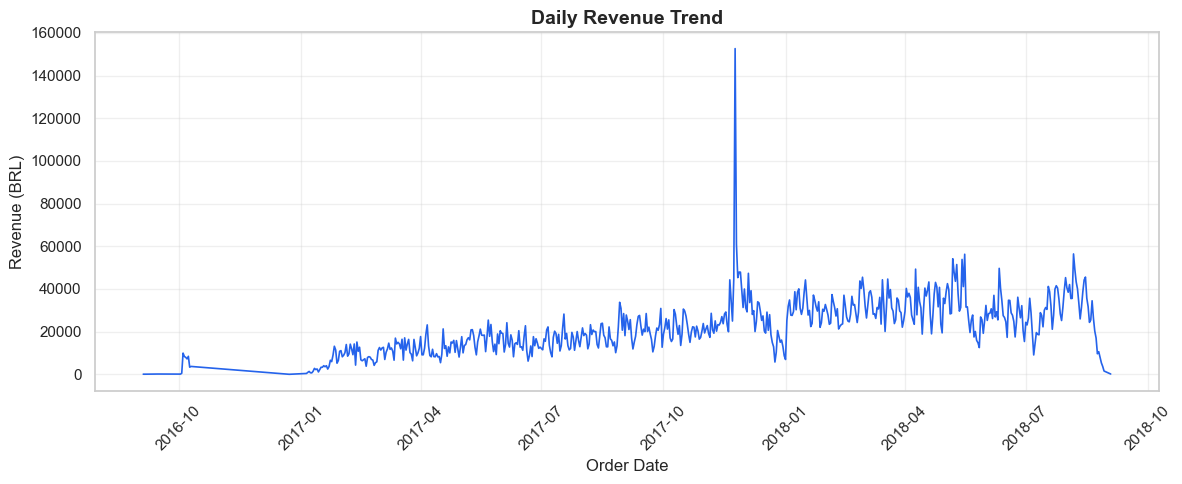

In [21]:
daily = run_sql('''
SELECT order_date, SUM(total_revenue) AS daily_revenue
FROM fact_sales GROUP BY order_date ORDER BY order_date
''')
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily["order_date"], daily["daily_revenue"], color="#2563eb", lw=1.2)
ax.set_title("Daily Revenue Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Order Date"); ax.set_ylabel("Revenue (BRL)")
ax.tick_params(axis="x", rotation=45); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


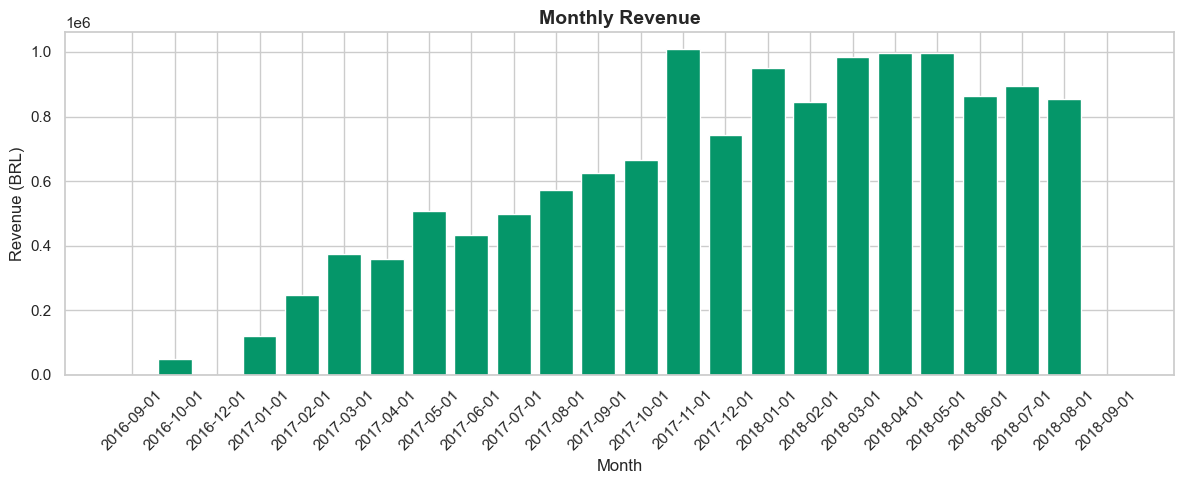

In [22]:
monthly = run_sql('''
SELECT DATE_TRUNC('month', order_date)::DATE AS m, SUM(total_revenue) AS revenue
FROM fact_sales GROUP BY 1 ORDER BY 1
''')
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly["m"].astype(str), monthly["revenue"], color="#059669")
ax.set_title("Monthly Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Revenue (BRL)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()


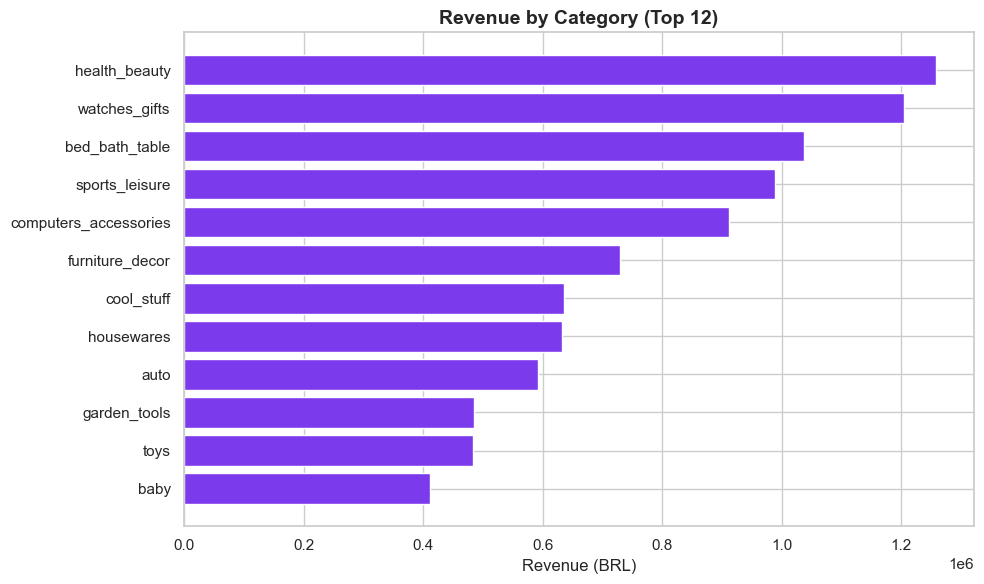

In [23]:
cats = run_sql('''
SELECT product_category, SUM(total_revenue) AS revenue FROM fact_sales
GROUP BY 1 ORDER BY revenue DESC LIMIT 12
''')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cats["product_category"], cats["revenue"], color="#7c3aed")
ax.set_title("Revenue by Category (Top 12)", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue (BRL)"); ax.invert_yaxis()
plt.tight_layout(); plt.show()


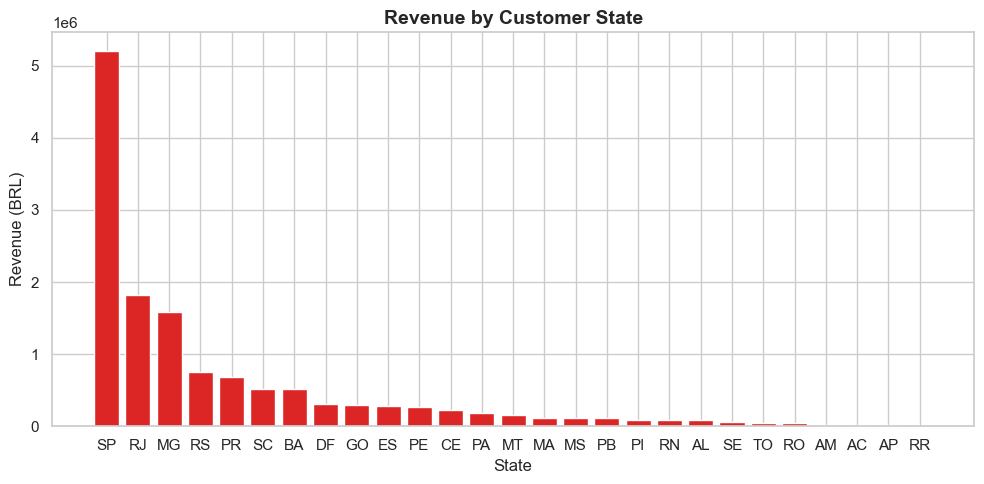

In [24]:
regions = run_sql('''
SELECT COALESCE(NULLIF(TRIM(c.region), ''), 'Unknown') AS region, SUM(f.total_revenue) AS revenue

FROM fact_sales f
JOIN staging_orders o
  ON f.order_id = o.order_id AND f.order_item_id = o.order_item_id
LEFT JOIN staging_customers c ON o.customer_id = c.customer_id
 GROUP BY 1 ORDER BY revenue DESC
''')
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(regions["region"], regions["revenue"], color="#dc2626")
ax.set_title("Revenue by Customer State", fontsize=14, fontweight="bold")
ax.set_xlabel("State"); ax.set_ylabel("Revenue (BRL)")
plt.tight_layout(); plt.show()


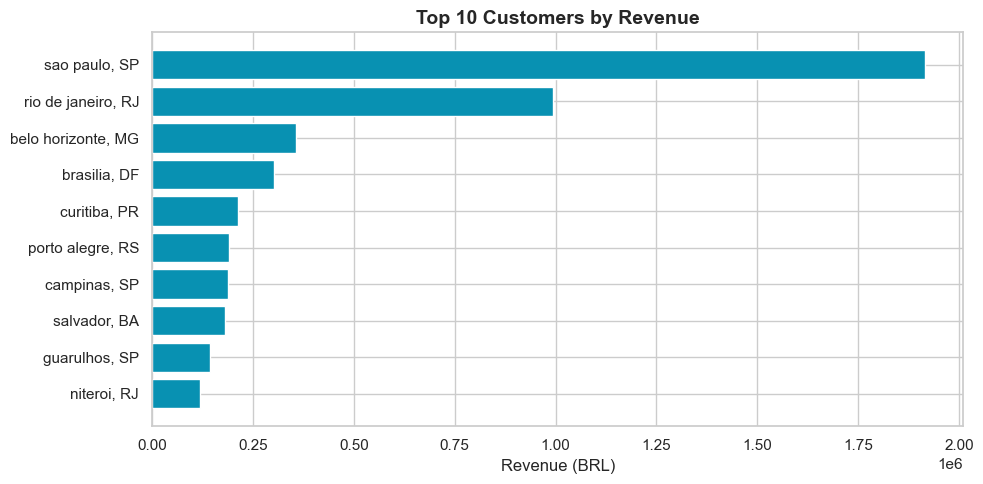

In [22]:
top10 = run_sql('''
SELECT COALESCE(c.customer_name, o.customer_id::text) AS customer, SUM(f.total_revenue) AS revenue

FROM fact_sales f
JOIN staging_orders o
  ON f.order_id = o.order_id AND f.order_item_id = o.order_item_id
LEFT JOIN staging_customers c ON o.customer_id = c.customer_id
 GROUP BY 1 ORDER BY revenue DESC LIMIT 10
''')
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10["customer"].str[:28], top10["revenue"], color="#0891b2")
ax.set_title("Top 10 Customers by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue (BRL)"); ax.invert_yaxis()
plt.tight_layout(); plt.show()


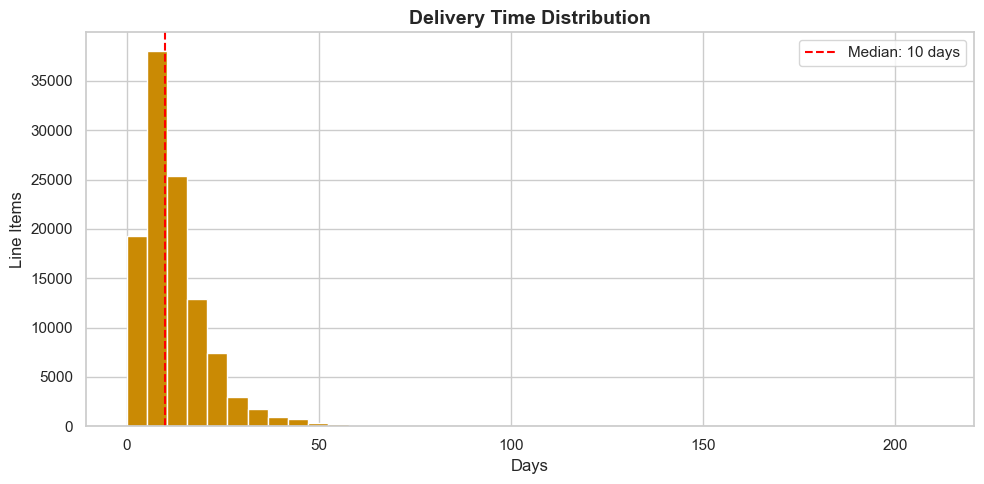

In [23]:
dt = df_fact["delivery_time"].dropna()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(dt, bins=40, color="#ca8a04", edgecolor="white")
ax.axvline(dt.median(), color="red", ls="--", label=f"Median: {dt.median():.0f} days")
ax.set_title("Delivery Time Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Days"); ax.set_ylabel("Line Items"); ax.legend()
plt.tight_layout(); plt.show()


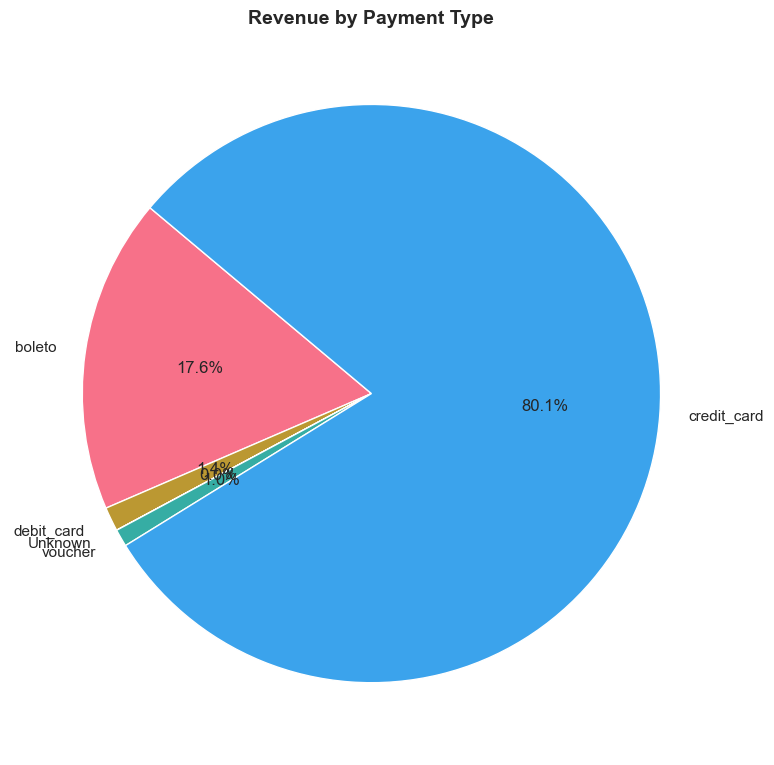

In [24]:
pay = run_sql('SELECT payment_type, SUM(total_revenue) AS revenue FROM fact_sales GROUP BY 1')
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(pay["revenue"], labels=pay["payment_type"], autopct="%1.1f%%", startangle=140)
ax.set_title("Revenue by Payment Type", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


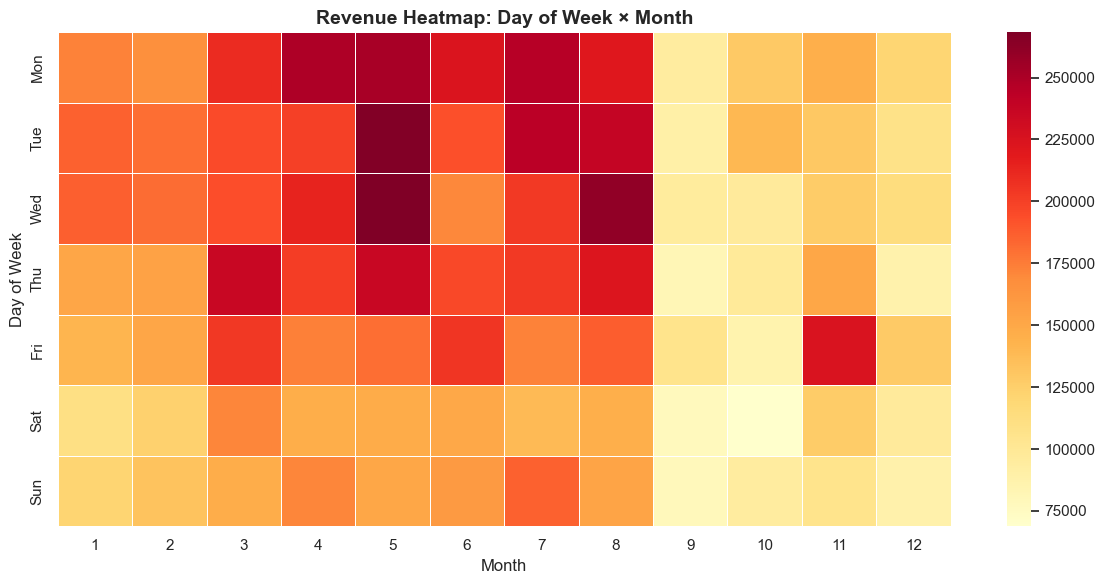

In [25]:
heat = q06_heatmap.pivot_table(index="day_of_week", columns="month_num", values="revenue", aggfunc="sum")
order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
heat = heat.reindex([d for d in order if d in heat.index])
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heat, cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Revenue Heatmap: Day of Week × Month", fontsize=14, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Day of Week")
plt.tight_layout(); plt.show()
